# Imports

In [1]:
import os
import warnings
from rich import print

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import palantir
import scvi
import torch

In [2]:
plt.rcParams['savefig.dpi'] = 300
%matplotlib inline

# Functions

In [3]:
def log_transform(ad, ps=0.1):
    """
    Applies a pseudo-count log2 transformation to the data in an AnnData object.

    The transformation is defined as log2(x + ps) - log2(ps), where x is the original data
    and ps is the pseudo-count. The purpose of the pseudo-count is to avoid taking the log of zero.

    Parameters
    ----------
    ad: AnnData
        The AnnData object containing the data to be transformed.

    ps: float, optional
        The pseudo-count to be added to the data before taking the logarithm.
        The default value is 0.1.

    Returns
    -------
    None
        The function modifies the AnnData object in-place.
    """

    # Check if the data in the Anndata object is a numpy array
    if not isinstance(ad.X.data, np.ndarray):
        raise TypeError("The data in the AnnData object should be a numpy array.")

    # Check if the pseudo-count is a positive number
    if ps <= 0:
        raise ValueError("The pseudo-count should be a positive number.")

    # Apply the log2 transformation
    ad.X.data = np.log2(ad.X.data + ps) - np.log2(ps)

# Load Data

In [4]:
input_dir = 'datasets'
data_name3 = 'Wright et al/adult-distal-colon/'

In [5]:
def read_files(filepath): 
    # for all the files in this directory
    # if it ends with barcodes.tsv, name it as barcodes
    # if it ends with genes.tsv, name it as genes
    # if it ends with matrix.mtx, name it as matrix
    files = os.listdir(filepath)
    files.sort(key=lambda f: int(f.split("_Colon_")[1].split("_")[0])) # Sort numerically: Colon_1, Colon_2, Colon_3
    barcodes = [f for f in files if f.endswith('barcodes.tsv.gz')]
    genes = [f for f in files if f.endswith('genes.tsv.gz')]
    matrix = [f for f in files if f.endswith('matrix.mtx.gz')]

    # extract the sample name before the last '_'
    sample = [f.split('_')[-2] for f in genes]

    # create a dictionary to store the sample number and the corresponding files type and read the file
    data = {}
    for i in range(len(sample)):
        data[sample[i]] = {}
        data[sample[i]]['genes'] = pd.read_csv(filepath + genes[i], sep='\t', index_col=0, header=None)
        data[sample[i]]['barcodes'] = pd.read_csv(filepath + barcodes[i], sep='\t', index_col=0, header=None)
        data[sample[i]]['matrix'] = sc.read(filepath + matrix[i])
    return data

In [6]:
distal_colon_cells_directory = os.path.join(input_dir, data_name3)
distal_colon_dir = read_files(distal_colon_cells_directory)

In [7]:
for sample, subdic in distal_colon_dir.items(): 
    ad = sc.AnnData(subdic['matrix'].X.T)
    ad.var_names = subdic['genes'][1]
    subdic['barcodes'].index.name = None  # Ensure the index name is None
    ad.obs_names = subdic['barcodes'].index
    ad.obs['sample'] = sample
    subdic['matrix'] = ad

In [8]:
for sample, subdic in distal_colon_dir.items(): 
    print(subdic['matrix'])

AnnData object with n_obs × n_vars = 643 × 27998
    obs: 'sample'

AnnData object with n_obs × n_vars = 676 × 27998
    obs: 'sample'

AnnData object with n_obs × n_vars = 343 × 27998
    obs: 'sample'

In [9]:
for sample, subdic in distal_colon_dir.items():
    sample_name = sample.split('-')[-1]
    ad = subdic['matrix']
    ad.obs_names = [sample_name + '_' + i for i in ad.obs_names]
    subdic['matrix'] = ad

In [10]:
for sample, subdic in distal_colon_dir.items(): 
    # make the feature names unique
    ad = subdic['matrix']
    ad.var_names_make_unique()
    subdic['matrix'] = ad

In [11]:
ad_wright_distal_colon = sc.AnnData.concatenate(*[subdic['matrix'] for sample, subdic in distal_colon_dir.items()], batch_key='batch', join = 'inner')

/loc/scratch/41954361/ipykernel_5248/3630546518.py:1: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  ad_wright_distal_colon = sc.AnnData.concatenate(*[subdic['matrix'] for sample, subdic in distal_colon_dir.items()], batch_key='batch', join = 'inner')


# Preprocessing

In [12]:
ad_wright_distal_colon.var["mt"] = ad_wright_distal_colon.var_names.str.startswith("mt")
sc.pp.calculate_qc_metrics(
    ad_wright_distal_colon,
    qc_vars=["mt"],
    inplace=True,
    percent_top=None,
    log1p=False,
)

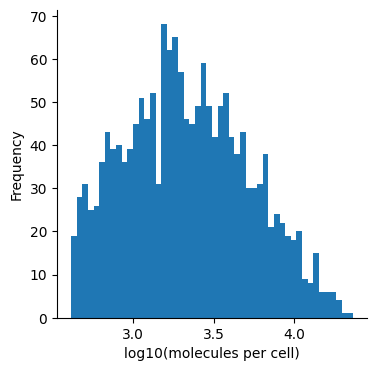

In [13]:
plt.figure()
ax = plt.gca()
ax.hist(np.log10(ad_wright_distal_colon.obs["total_counts"]), bins=50)
ax.set_xlabel("log10(molecules per cell)")
ax.set_ylabel("Frequency")
plt.show()

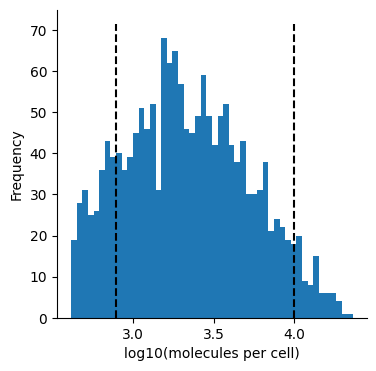

In [14]:
THRESHOLDS = np.log10(np.percentile((ad_wright_distal_colon.obs["total_counts"]), [15, 95]))

plt.figure()
ax = plt.gca()
ax.hist(np.log10(ad_wright_distal_colon.obs["total_counts"]), bins=50)
ax.vlines(
    THRESHOLDS,
    ymin=ax.get_ylim()[0],
    ymax=ax.get_ylim()[1],
    color="black",
    linestyle="--",
)
ax.set_xlabel("log10(molecules per cell)")
ax.set_ylabel("Frequency")
plt.show()

In [15]:
use_cells = ad_wright_distal_colon.obs_names[
    (np.log10(ad_wright_distal_colon.obs["total_counts"]) > THRESHOLDS[0])
    & (np.log10(ad_wright_distal_colon.obs["total_counts"]) < THRESHOLDS[1])
]
ad_wright_distal_colon = ad_wright_distal_colon[use_cells, :]

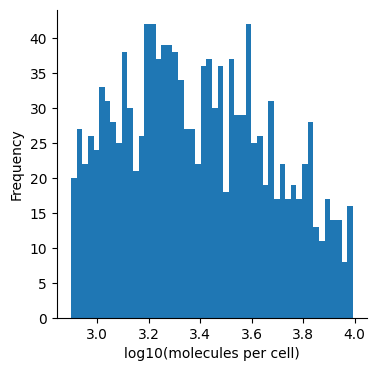

In [16]:
plt.figure()
ax = plt.gca()
ax.hist(np.log10(ad_wright_distal_colon.obs["total_counts"]), bins=50)
ax.set_xlabel("log10(molecules per cell)")
ax.set_ylabel("Frequency")
plt.show()

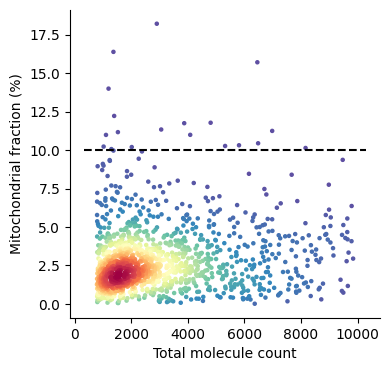

In [17]:
MITO_THRESHOLD = 10
x, y, dens = palantir.plot.density_2d(ad_wright_distal_colon.obs["total_counts"], ad_wright_distal_colon.obs["pct_counts_mt"])

plt.figure()
ax = plt.gca()
ax.scatter(x, y, c=dens, s=5)
ax.hlines(
    MITO_THRESHOLD,
    xmin=ax.get_xlim()[0],
    xmax=ax.get_xlim()[1],
    colors="black",
    linestyles="--",
)
plt.xlabel("Total molecule count")
plt.ylabel("Mitochondrial fraction (%)")
plt.show()

In [18]:
ad_wright_distal_colon = ad_wright_distal_colon[ad_wright_distal_colon.obs["pct_counts_mt"] < MITO_THRESHOLD, :]

In [19]:
# Filter nGenes = 200-5000
ad_wright_distal_colon = ad_wright_distal_colon[ad_wright_distal_colon.obs['n_genes_by_counts'] > 200].copy()
ad_wright_distal_colon = ad_wright_distal_colon[ad_wright_distal_colon.obs['n_genes_by_counts'] < 5000].copy()

In [20]:
sc.pp.filter_genes(ad_wright_distal_colon, min_cells=50)

In [21]:
ad_wright_distal_colon.shape

(1309, 9769)

In [22]:
ad_wright_distal_colon.layers['raw_counts'] = ad_wright_distal_colon.X.copy()

sc.pp.normalize_total(ad_wright_distal_colon)
ad_wright_distal_colon.layers["normalized_counts"] = ad_wright_distal_colon.X.copy()

log_transform(ad_wright_distal_colon)
ad_wright_distal_colon.layers["logcounts"] = ad_wright_distal_colon.X.copy()

In [23]:
sc.pp.highly_variable_genes(ad_wright_distal_colon, flavor="cell_ranger", n_top_genes=2500)

In [24]:
sc.tl.pca(ad_wright_distal_colon, mask_var="highly_variable")

In [25]:
sc.pp.neighbors(ad_wright_distal_colon, use_rep="X_pca")
sc.tl.umap(ad_wright_distal_colon)

/loc/scratch/41954361/ipykernel_5248/2448038929.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(ad_wright_distal_colon, resolution=0.6, key_added="leiden_0.6")


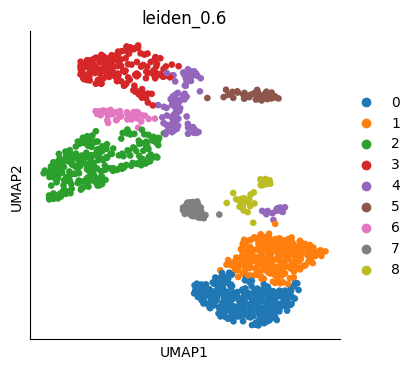

In [26]:
sc.tl.leiden(ad_wright_distal_colon, resolution=0.6, key_added="leiden_0.6")
sc.pl.umap(ad_wright_distal_colon, color="leiden_0.6")

In [27]:
ad_wright_distal_colon.obs["log_n_counts"] = np.log10(ad_wright_distal_colon.obs["total_counts"])

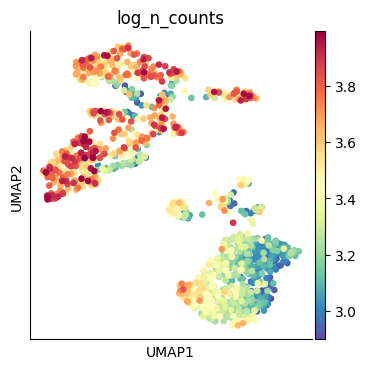

In [28]:
sc.pl.umap(ad_wright_distal_colon, color="log_n_counts")

In [29]:
sc.pp.scrublet(ad_wright_distal_colon)

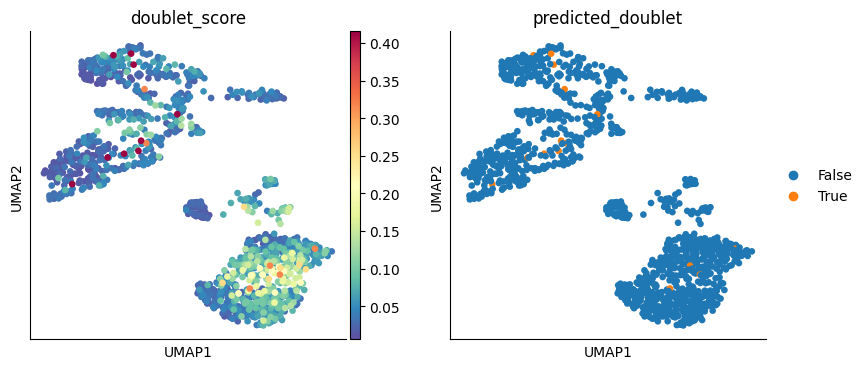

In [30]:
sc.pl.umap(ad_wright_distal_colon, color=["doublet_score", "predicted_doublet"])

In [31]:
ad_wright_distal_colon = ad_wright_distal_colon[ad_wright_distal_colon.obs['predicted_doublet'] == False]

In [32]:
sc.pp.highly_variable_genes(ad_wright_distal_colon, flavor="cell_ranger", n_top_genes=2500)
sc.tl.pca(ad_wright_distal_colon, mask_var="highly_variable")
sc.pp.neighbors(ad_wright_distal_colon, use_rep="X_pca")
sc.tl.umap(ad_wright_distal_colon)

/app/software/scanpy/1.10.4-foss-2024a/lib/python3.12/site-packages/scanpy/preprocessing/_highly_variable_genes.py:696: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["hvg"] = {"flavor": flavor}


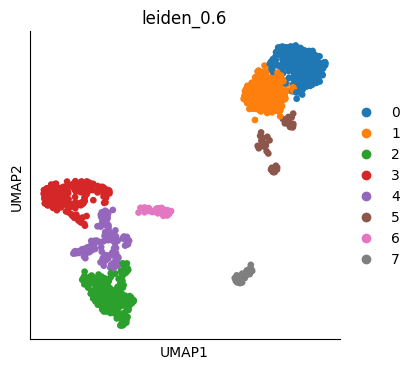

In [33]:
sc.tl.leiden(ad_wright_distal_colon, resolution=0.6, key_added="leiden_0.6")
sc.pl.umap(ad_wright_distal_colon, color="leiden_0.6")

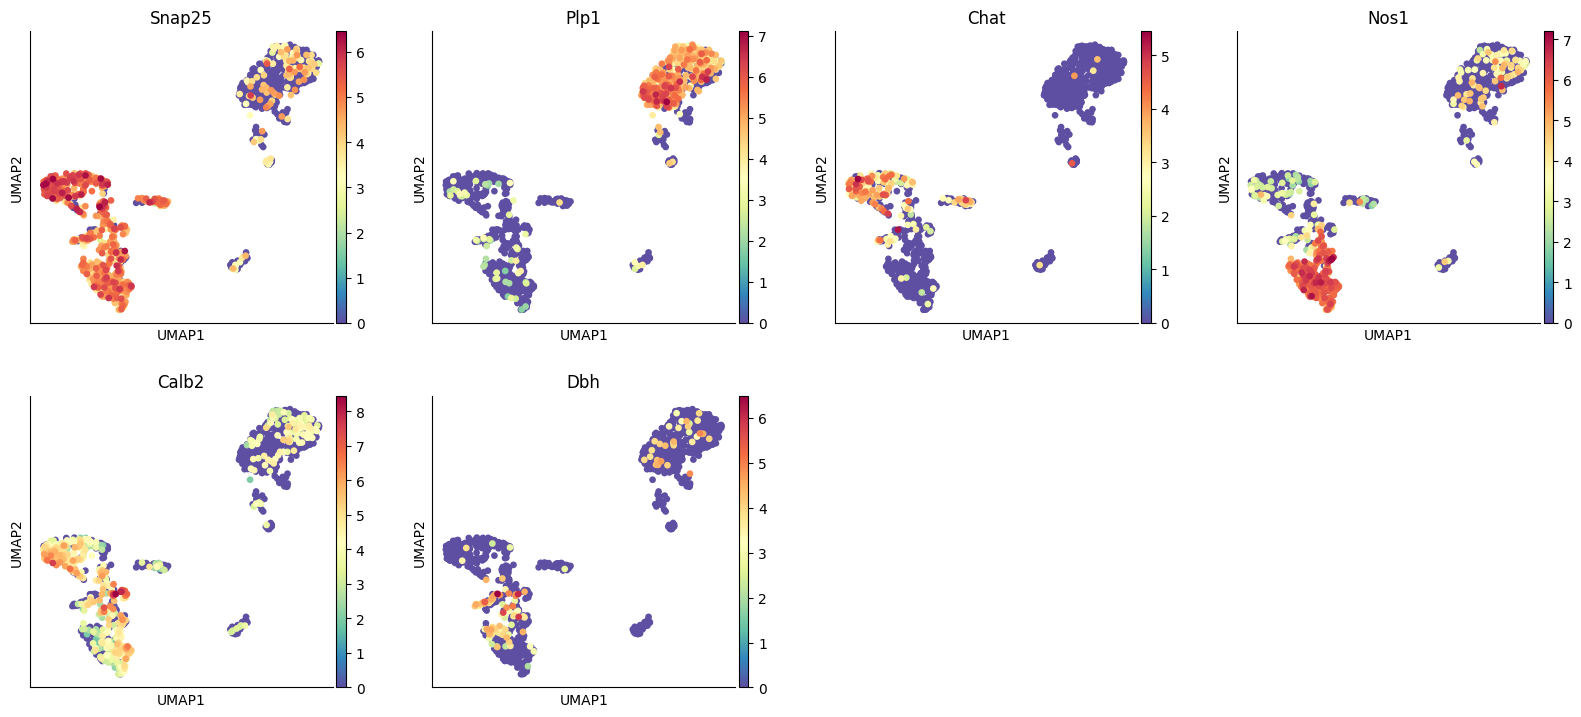

In [47]:
sc.pl.umap(ad_wright_distal_colon, color=['Snap25', 'Plp1', 'Chat', 'Nos1', 'Calb2', 'Dbh'])

In [48]:
ad_wright_distal_colon = ad_wright_distal_colon[ad_wright_distal_colon.obs['leiden_0.6'].isin(['2', '3', '4', '6'])]

In [49]:
sc.pp.highly_variable_genes(ad_wright_distal_colon, flavor="cell_ranger", n_top_genes=2500)
sc.tl.pca(ad_wright_distal_colon, mask_var="highly_variable")
sc.pp.neighbors(ad_wright_distal_colon, use_rep="X_pca")
sc.tl.umap(ad_wright_distal_colon)

/app/software/scanpy/1.10.4-foss-2024a/lib/python3.12/site-packages/scanpy/preprocessing/_highly_variable_genes.py:696: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["hvg"] = {"flavor": flavor}


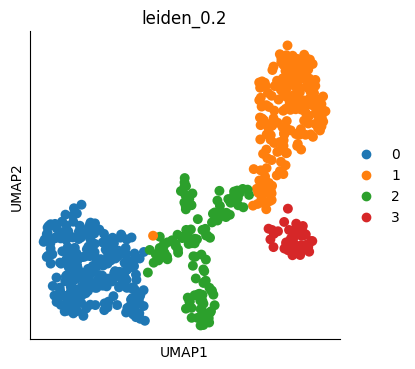

In [50]:
sc.tl.leiden(ad_wright_distal_colon, resolution=0.2, key_added="leiden_0.2")
sc.pl.umap(ad_wright_distal_colon, color="leiden_0.2")

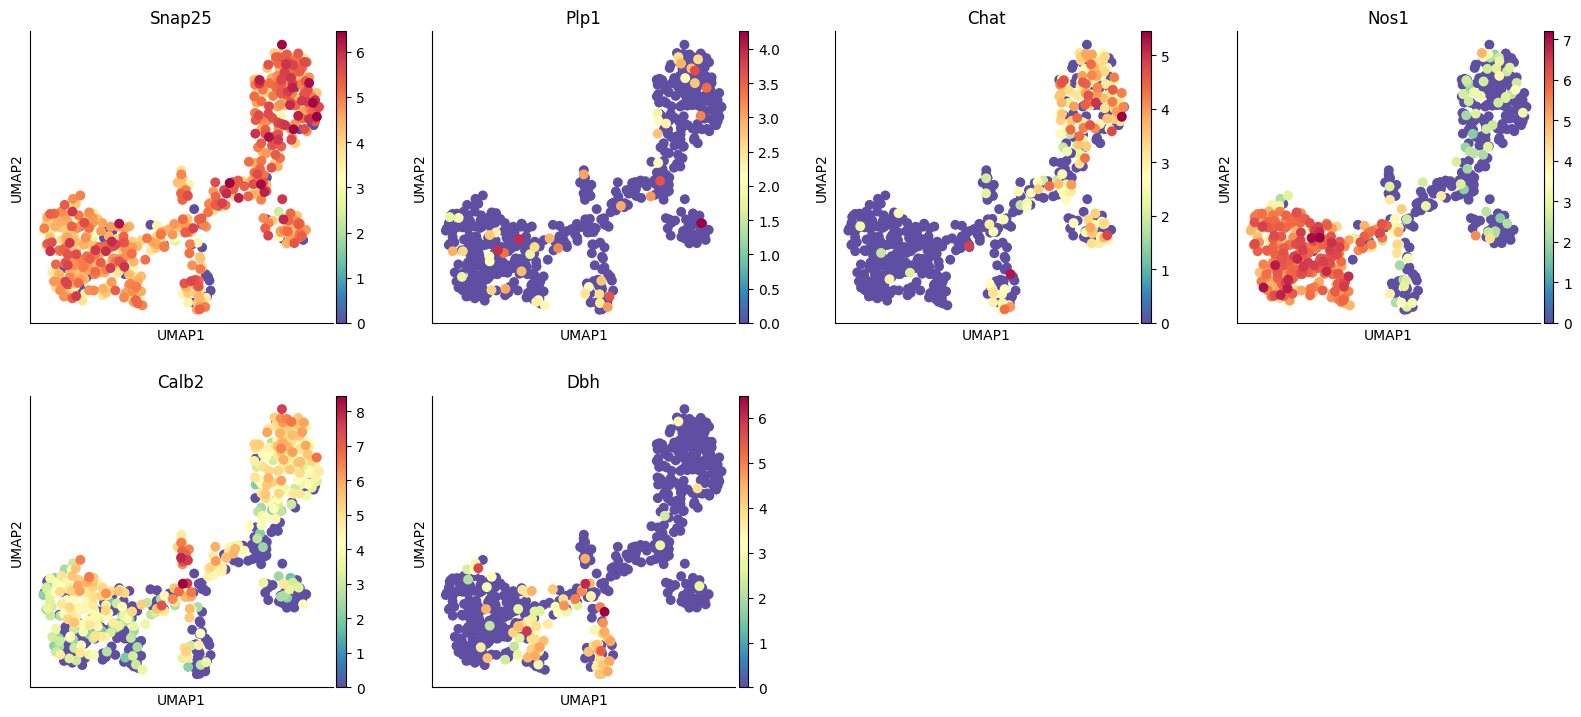

In [51]:
sc.pl.umap(ad_wright_distal_colon, color=['Snap25', 'Plp1', 'Chat', 'Nos1', 'Calb2', 'Dbh'])

In [52]:
ad_wright_distal_colon.shape

(591, 9769)

# Save AnnData Object

In [53]:
ad_wright_distal_colon.write_h5ad('wright_preprocessed.h5ad')